In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- apple_products_pricing_2020_2026
- clean_dataset


In [3]:
for table in tables:
       print(f"\n Table: {table}")
       query = text(f"SELECT * FROM {table}")
       df = pd.read_sql_query(query, engine)
       display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine))


 Table: apple_products_pricing_2020_2026


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.4,-1.6,,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.4,-1.7,,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.4,1.5,,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.7,0.9,,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.3,-1.7,,In Stock,4.7,35



 Table: clean_dataset


,price_recorded_date,platform,product_category,model_name,condition,launch_price_usd,launch_price_inr,current_price_usd,current_price_inr,discount_pct,sale_event,stock_status,rating,reviews_count,year,month
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.4,-1.6,No Sale Event,In Stock,4.7,40,2020,9
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.4,-1.7,No Sale Event,Out of Stock,4.6,84,2020,9
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.4,1.5,No Sale Event,In Stock,4.4,110,2020,9
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.7,0.9,No Sale Event,In Stock,4.8,111,2020,9
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.3,-1.7,No Sale Event,In Stock,4.7,35,2020,9


In [4]:
df = pd.read_sql_query(text("SELECT * FROM clean_dataset"), engine)

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_recorded_date,80000,2024-09-14 22:14:06.359999744,2020-09-19 00:00:00,2023-11-03 00:00:00,2024-12-22 00:00:00,2025-10-27 00:00:00,2026-07-31 00:00:00,NaN
launch_price_usd,80000.0,963.959125,329.0,599.0,799.0,1199.0,1999.0,470.086413
launch_price_inr,80000.0,94467.99425,32242.0,58702.0,78302.0,117502.0,195902.0,46068.468464
current_price_usd,80000.0,782.769855,109.93,432.93,699.74,989.1125,2038.97,461.67397
current_price_inr,80000.0,74628.342369,9157.68,41686.825,67324.05,96568.125,203669.0,45117.872002
discount_pct,80000.0,21.418826,-2.0,6.7,21.3,36.8,73.1,16.69731
rating,80000.0,4.450099,3.8,4.3,4.4,4.7,4.9,0.269782
reviews_count,80000.0,2405.995925,10.0,896.0,1893.5,3383.0,11526.0,1973.630852
year,80000.0,2024.216225,2020.0,2023.0,2024.0,2025.0,2026.0,1.405657
month,80000.0,6.401112,1.0,3.0,6.0,10.0,12.0,3.46496


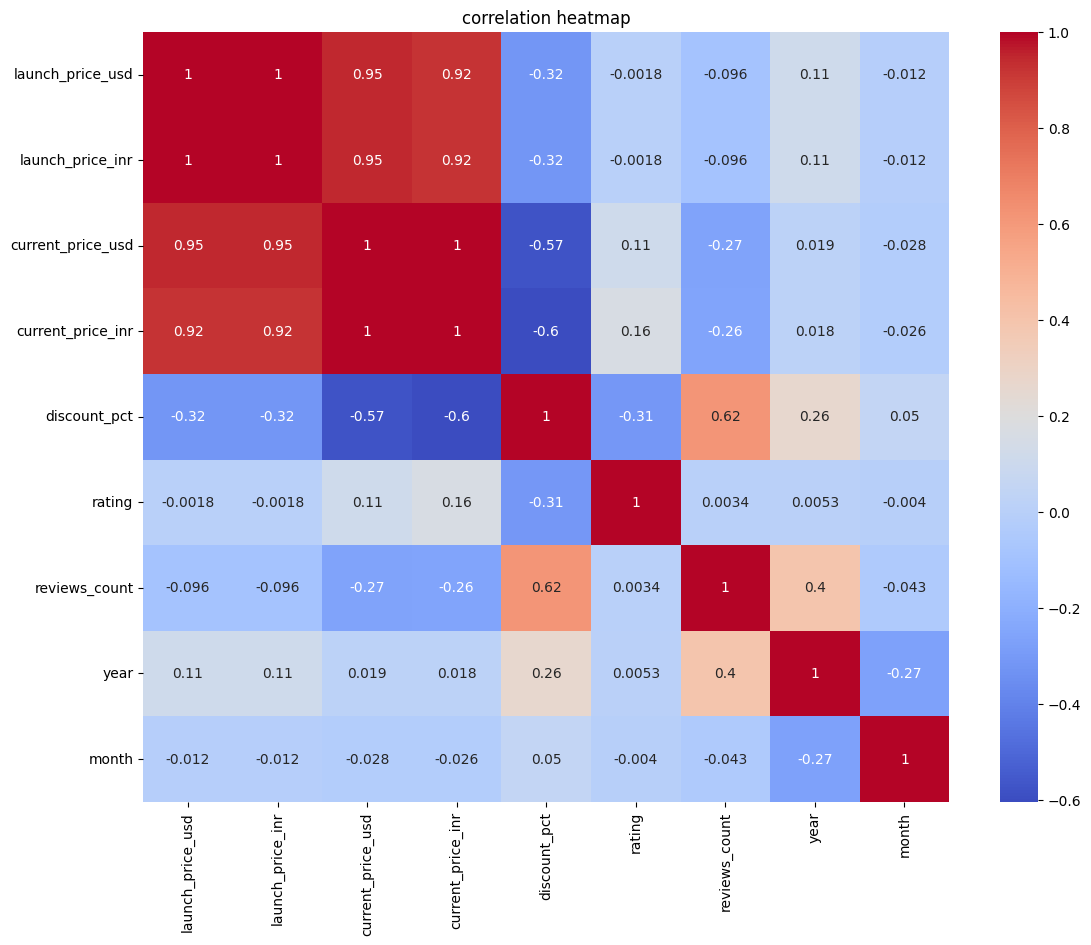

In [6]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(13,10))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

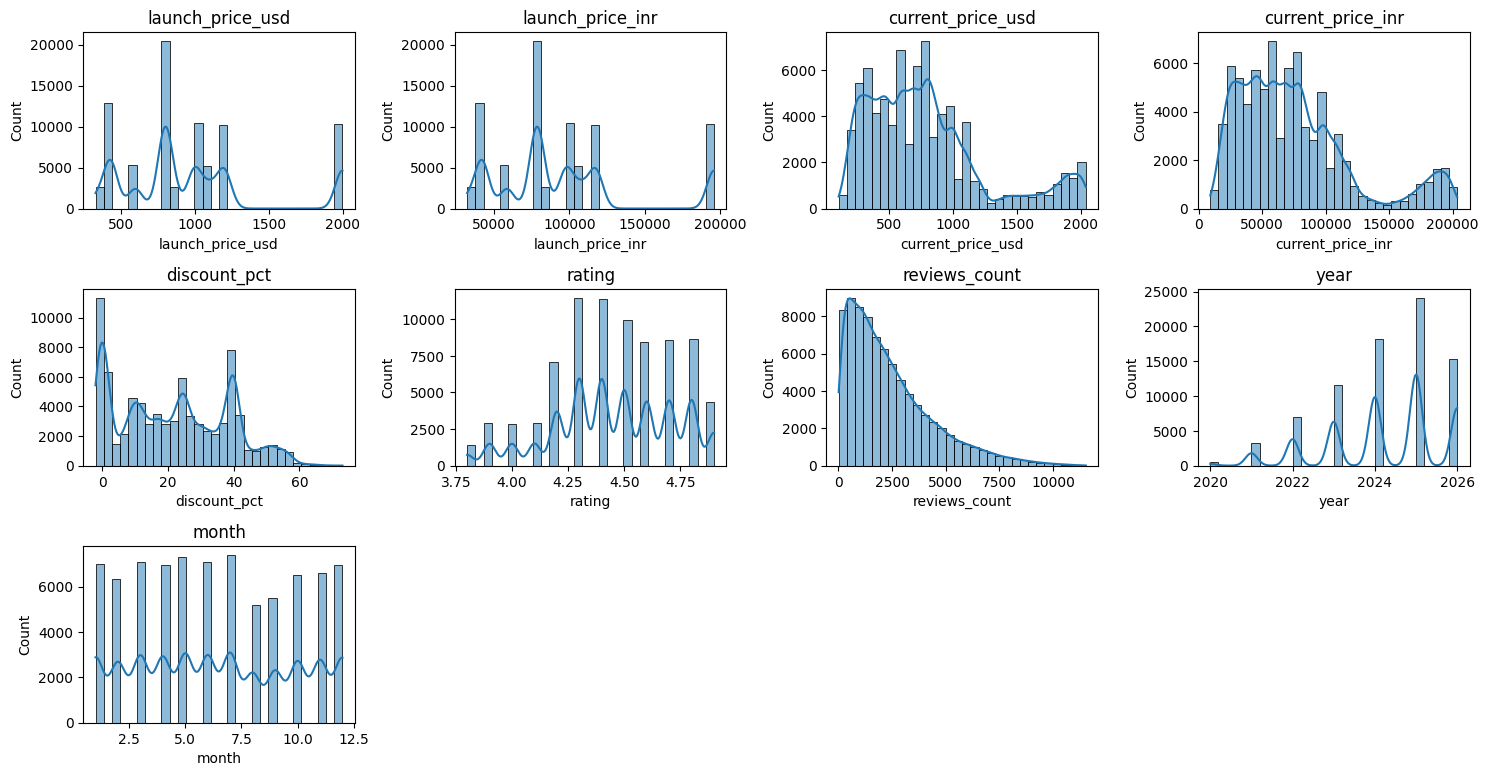

In [7]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

# Phase 1 : Business Overview & KPI

1 . What is the overall average discount percentage across the entire catalog, and how has it trended year-over-year (2020–2026)?

,avg_discount
0,21.42


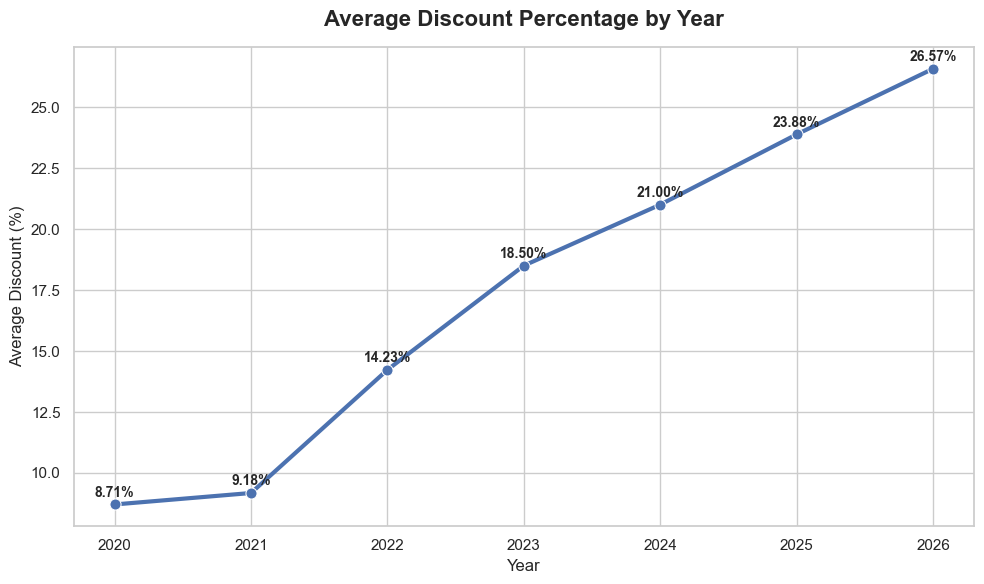

In [14]:
overall_discount = pd.read_sql_query(text("""select round(avg(discount_pct),2) as avg_discount from clean_dataset; """),engine)
display(overall_discount)

yearly_discount = pd.read_sql_query(text("""select year , round(avg(discount_pct),2) as avg_discount from clean_dataset group by year order by year; """),engine)
# display(yearly_discount)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10,6))

# Line chart
ax = sns.lineplot(
    data=yearly_discount,
    x="year",
    y="avg_discount",
    marker="o",
    linewidth=3,
    markersize=8
)

# Title & Labels
ax.set_title("Average Discount Percentage by Year",
             fontsize=16,
             fontweight="bold",
             pad=15)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average Discount (%)", fontsize=12)

# Add data labels
for x, y in zip(yearly_discount["year"], yearly_discount["avg_discount"]):
    ax.text(
        x,
        y + 0.2,              # Slightly above the marker
        f"{y:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Improve layout
plt.xticks(yearly_discount["year"])
plt.tight_layout()

plt.show()

2 . What is the average price gap between "New" and "Renewed/Refurbished" condition for the same model?

In [18]:
avg_price_gap = pd.read_sql_query(text("""with a as (select model_name , round(avg(case when `condition` = "New" then current_price_inr end),2) as new_,
round(avg(case when `condition` = "Renewed/Refurbished" then current_price_inr end),2) as Renewed_Refurbished_
from clean_dataset group by model_name)
select round(avg(new_ - Renewed_Refurbished_),2) as avg_price_gap_inr from a;
;"""),engine)
display(avg_price_gap)

,avg_price_gap_inr
0,26685.78


3 . Which product category (iPhone/iPad/Mac/Watch) contributes the most price-tracked listings, and does that match where the biggest discounts happen?

In [ ]:
category_contribute = pd.read_sql_query(text("""select product_category , count(*) as total_record , round(avg(discount_pct),2) as avg_discount , ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_total_listings from clean_dataset group by product_category order by avg_discount desc"""),engine)
display(category_contribute)

,product_category,total_record,avg_discount,pct_of_total_listings
0,Watch,17865,26.27,22.33
1,iPad,15526,26.19,19.41
2,iPhone,28589,19.57,35.74
3,Mac,18020,15.43,22.53


4 . What is the average Current_Price_USD vs Launch_Price_USD ratio across the whole catalog — are products, on average, selling above or below launch price?

In [31]:
avg_usd = pd.read_sql_query(text("""select round(avg(launch_price_usd),2) as avg_lunch_price_usd , round(avg(current_price_usd),2) as avg_current_price_usd , round(avg(current_price_usd) / avg(launch_price_usd),4) as avg_ratio, round(
avg(launch_price_usd - current_price_usd)
, 2) as price_diff , CASE 
        WHEN AVG(current_price_usd) < AVG(launch_price_usd) THEN 'Below launch price'
        ELSE 'Above launch price'
    END AS selling_vs_launch from clean_dataset; """),engine)
display(avg_usd)

,avg_lunch_price_usd,avg_current_price_usd,avg_ratio,price_diff,selling_vs_launch
0,963.96,782.77,0.812,181.19,Below launch price


5 . How does the USD-to-INR price ratio compare to the official/expected exchange rate — is Indian pricing systematically higher or lower after conversion?

In [33]:
usd_inr = pd.read_sql_query(text("""SELECT 
    product_category,
    COUNT(*) AS record_count,
    round(AVG(current_price_inr * 1.0 / current_price_usd),2) AS avg_implied_rate,
    AVG(CASE WHEN (current_price_inr * 1.0 / current_price_usd) < 98 THEN 1 ELSE 0 END) * 100 AS pct_below_official
FROM clean_dataset
GROUP BY product_category
ORDER BY product_category, avg_implied_rate; """),engine)
display(usd_inr)

,product_category,record_count,avg_implied_rate,pct_below_official
0,iPad,15526,94.73,62.3470
1,iPhone,28589,94.82,61.5202
2,Mac,18020,94.72,62.9467
3,Watch,17865,94.70,62.0823


# phase 2 : product performance analysis

6 . Which 5 models sustain the highest average rating despite having a large Reviews_Count (i.e., proven at scale, not just a few enthusiastic reviewers)?

In [44]:
model_rate = pd.read_sql_query(text("""select model_name, round(avg(rating),2) as avg_rate from clean_dataset where reviews_count >= 150 group by model_name order by avg_rate desc limit 5 ; """),engine)
display(model_rate)

,model_name,avg_rate
0,iPad Air (5th Gen) 64GB,4.46
1,iPhone 14 Pro 128GB,4.46
2,Apple Watch Series 8 (45mm),4.46
3,iPhone 14 128GB,4.46
4,MacBook Pro 14-inch M3 Pro 512GB,4.46


7 . Is there a relationship between a model's Discount_Pct and its Reviews_Count — do heavily discounted products get reviewed more?

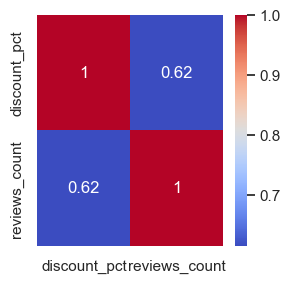

,mean,count
discount_pct_tier,,
Heavy Discount,4390.78,236
High Discount,3200.93,20506
Low Discount,1293.91,15975
Moderate Discount,2098.24,21967
No Discount,665.30,468
Price Above Launch,686.92,8669
Very High Discount,4333.42,12179


In [58]:
column_name = ['discount_pct','reviews_count']
plt.figure(figsize=(3, 3))
sns.heatmap(df[column_name].corr(), annot=True, cmap="coolwarm")
plt.show()

def get_discount_tier(discount):
    if discount < 0:
        return 'Price Above Launch'
    elif discount == 0:
        return 'No Discount'
    elif 0 < discount <= 10:
        return 'Low Discount'
    elif 10 < discount <= 25:
        return 'Moderate Discount'
    elif 25 < discount <= 40:
        return 'High Discount'
    elif 40 < discount <= 60:
        return 'Very High Discount'
    else:
        return 'Heavy Discount'



df['discount_pct_tier'] = df['discount_pct'].apply(get_discount_tier)

tier_stats = df.groupby('discount_pct_tier')['reviews_count'].agg(
    mean='mean', count='count'
).round(2)

display(tier_stats)

8 . Which category (iPhone/iPad/Mac/Watch) holds its rating best over its lifecycle vs. which one sees ratings decline as it ages?

In [61]:
avg_rate = pd.read_sql_query(text("""select year , round(avg(case when product_category = "Watch" then rating end),2) as watch ,  round(avg(case when product_category = "iPhone" then rating end),2) as iphone,round(avg(case when product_category = "Mac" then rating end),2) as mac,round(avg(case when product_category = "iPad" then rating end),2) as ipad from clean_dataset group by year order by year"""),engine)
display(avg_rate)

,year,watch,iphone,mac,ipad
0,2020,4.47,4.43,4.48,4.43
1,2021,4.44,4.45,4.42,4.45
2,2022,4.45,4.45,4.45,4.45
3,2023,4.45,4.46,4.45,4.45
4,2024,4.44,4.45,4.45,4.45
5,2025,4.45,4.45,4.45,4.45
6,2026,4.44,4.46,4.45,4.46


9 . Do "Pro"/"Pro Max"/"Ultra" tier models show different rating or discount behavior than base models within the same category?

In [69]:
model_behaviour = pd.read_sql_query(text(""" select case when model_name like "%Pro Max%" then 'pro_max_model'
when model_name like "%Pro%" then 'pro_model'
when model_name like "%Ultra%" then 'ultra_model' 
else "base_models"
end as model_category , product_category , round(avg(rating),2) as avg_rate,
round(avg(discount_pct),2) as avg_discount , count(*) as total_record
from clean_dataset group by model_category, product_category;
"""),engine)
display(model_behaviour)


,model_category,product_category,avg_rate,avg_discount,total_record
0,base_models,Watch,4.45,28.30,12828
1,base_models,iPad,4.45,32.28,7833
2,base_models,iPhone,4.45,19.77,15466
3,pro_model,iPhone,4.45,20.12,7973
4,base_models,Mac,4.45,20.00,7749
5,pro_model,iPad,4.45,19.98,7693
6,pro_max_model,iPhone,4.44,18.14,5150
7,pro_model,Mac,4.45,11.98,10271
8,ultra_model,Watch,4.44,21.09,5037


10 . Which models show the widest spread (max–min) in Current_Price_USD across their lifetime — i.e., the most price-volatile products?

In [72]:
model_spred = pd.read_sql_query(text("""select model_name , round(max(current_price_usd) - min(current_price_usd),2) as price_spread from clean_dataset group by model_name order by price_spread desc """),engine)
display(model_spred)

,model_name,price_spread
0,MacBook Pro 14-inch M1 Pro 512GB,1090.54
1,MacBook Pro 14-inch M2 Pro 512GB,1069.00
2,MacBook Pro 14-inch M3 Pro 512GB,993.20
3,MacBook Pro 14-inch M4 Pro 512GB,988.94
4,iPhone 13 Pro Max 256GB,868.89
5,MacBook Air M2 256GB,791.62
6,iPhone 15 Pro Max 256GB,751.03
7,iPhone 12 Pro 128GB,750.46
8,iPad Pro 12.9-inch (M2) 256GB,707.66
9,iPhone 14 Pro 128GB,692.25


# phase 3 : pricing & discount stretegy

11 . What is the average discount percentage by Product_Category — which category is discounted most aggressively?

In [74]:
category_discount = pd.read_sql_query(text("""select product_category , count(*) as total_record , round(avg(discount_pct),2) as avg_discount from clean_dataset group by product_category order by avg_discount desc"""),engine)
display(category_discount)

,product_category,total_record,avg_discount
0,Watch,17865,26.27
1,iPad,15526,26.19
2,iPhone,28589,19.57
3,Mac,18020,15.43


12 . How does Discount_Pct differ between "New" and "Renewed/Refurbished" condition for the same model?

In [77]:
model_condition = pd.read_sql_query(text("""with a as (select model_name , round(avg(case when `condition` = "New" then discount_pct end),2) as new_condition,
round(avg(case when `condition` = "Renewed/Refurbished" then discount_pct end),2) as Renewed_Refurbished 
from clean_dataset group by model_name)
select model_name , new_condition , Renewed_Refurbished , round(new_condition - Renewed_Refurbished) as diffrence from a;"""),engine)
display(model_condition)

,model_name,new_condition,Renewed_Refurbished,diffrence
0,Apple Watch Series 6 (44mm),30.85,46.23,-15.0
1,iPad Air (4th Gen) 64GB,28.37,44.35,-16.0
2,iPhone 12 64GB,26.40,42.75,-16.0
3,iPhone 12 Pro 128GB,24.45,41.59,-17.0
4,MacBook Air M1 256GB,23.78,40.33,-17.0
5,iPad Pro 11-inch (M1) 128GB,24.36,41.87,-18.0
6,iPhone 13 128GB,23.51,40.39,-17.0
7,iPhone 13 Pro Max 256GB,17.02,35.86,-19.0
8,iPad (9th Gen) 64GB,30.71,45.99,-15.0
9,Apple Watch Series 7 (45mm),28.87,45.62,-17.0


13 . Do iPhones and Macs follow different discounting philosophies (e.g., slower/shallower vs faster/deeper)?

In [82]:
iphon_mac = pd.read_sql_query(text("""select product_category , round(avg(discount_pct),2) as avg_discount , max(discount_pct) as max_discount , ROUND(STDDEV(discount_pct), 2) as std_dev,count(*) as total_record from clean_dataset where product_category in ("iPhone" , "Mac") group by product_category"""),engine)
display(iphon_mac)

,product_category,avg_discount,max_discount,std_dev,total_record
0,iPhone,19.57,73.1,16.14,28589
1,Mac,15.43,66.7,13.61,18020


# Phase 4 : platform comparision

14 . Which platform offers a lower average Current_Price_USD/INR for identical models, and by how much?

In [89]:
platform_price = pd.read_sql_query(text("""select model_name , round(avg(case when platform = "Flipkart" then current_price_usd end),2) as flipcart_avg_price_usd , 
round(avg(case when platform = "Amazon" then current_price_usd end),2) as amzon_avg_price_usd ,
round(avg(case when platform = "Flipkart" then current_price_inr end),2) as flipKart_avg_price_inr , 
round(avg(case when platform = "Amazon" then current_price_inr end),2) as amzon_avg_price_inr , ROUND(
        AVG(CASE WHEN platform = 'Flipkart' THEN current_price_usd END) - 
        AVG(CASE WHEN platform = 'Amazon' THEN current_price_usd END), 
    2) AS flipkart_minus_amazon_usd_diff  from clean_dataset 
group by model_name; """),engine)
display(platform_price)

,model_name,flipcart_avg_price_usd,amzon_avg_price_usd,flipKart_avg_price_inr,amzon_avg_price_inr,flipkart_minus_amazon_usd_diff
0,Apple Watch Series 6 (44mm),279.21,281.14,26569.91,26864.15,-1.93
1,iPad Air (4th Gen) 64GB,402.24,405.89,38188.42,38730.20,-3.65
2,iPhone 12 64GB,556.35,554.87,53112.91,52832.81,1.49
3,iPhone 12 Pro 128GB,715.18,706.92,68149.48,67341.17,8.26
4,MacBook Air M1 256GB,723.94,713.38,68961.47,67855.28,10.55
5,iPad Pro 11-inch (M1) 128GB,570.39,568.15,54414.42,54140.22,2.24
6,iPhone 13 128GB,576.63,581.75,55085.47,55556.44,-5.12
7,iPhone 13 Pro Max 256GB,942.94,930.24,89697.43,88721.01,12.70
8,iPad (9th Gen) 64GB,214.16,215.75,20394.25,20534.83,-1.59
9,Apple Watch Series 7 (45mm),282.66,290.35,26883.92,27708.04,-7.69


15 . Which platform runs deeper discounts during their respective flagship sale events (Prime Day vs Big Billion Days/Great Indian Festival)?

In [93]:
sale_discount = pd.read_sql_query(text("""select platform , sale_event , round(avg(discount_pct),2) as avg_discount from clean_dataset where  sale_event IN ('Prime Day', 'Big Billion Days', 'Great Indian Festival') group by platform , sale_event"""),engine)
display(sale_discount)

,platform,sale_event,avg_discount
0,Flipkart,Big Billion Days,37.02
1,Amazon,Great Indian Festival,33.45
2,Amazon,Prime Day,34.44


16 . Does Stock_Status behavior differ between platforms — is one platform more prone to "Out of Stock" or "Low Stock" for the same model?

In [5]:
stock_status = pd.read_sql_query(text("""select stock_status , platform  , count(*) as total_record from clean_dataset group by stock_status , platform"""),engine)
display(stock_status)

,stock_status,platform,total_record
0,In Stock,Flipkart,27521
1,Out of Stock,Flipkart,6788
2,In Stock,Amazon,27513
3,Low Stock,Amazon,5757
4,Out of Stock,Amazon,6687
5,Low Stock,Flipkart,5734


17 . Which platform maintains a better average rating for identical models — does platform-specific service/logistics correlate with customer sentiment?

In [9]:
platform_maintain = pd.read_sql_query(text("""
select model_name , round(avg(case when platform = "Amazon" then rating end),2) as amazon_avg_rate , 
round(avg(case when platform = "Flipkart" then rating end),2) as flipkart_avg_rate,
ROUND(
        AVG(CASE WHEN platform='Amazon' THEN rating END) -
        AVG(CASE WHEN platform='Flipkart' THEN rating END),
    2) AS rating_difference
from clean_dataset group by model_name; """),engine)
display(platform_maintain)

,model_name,amazon_avg_rate,flipkart_avg_rate,rating_difference
0,Apple Watch Series 6 (44mm),4.46,4.45,0.01
1,iPad Air (4th Gen) 64GB,4.46,4.44,0.03
2,iPhone 12 64GB,4.45,4.46,-0.01
3,iPhone 12 Pro 128GB,4.45,4.44,0.01
4,MacBook Air M1 256GB,4.45,4.45,0.00
5,iPad Pro 11-inch (M1) 128GB,4.45,4.45,0.00
6,iPhone 13 128GB,4.45,4.46,-0.02
7,iPhone 13 Pro Max 256GB,4.45,4.43,0.02
8,iPad (9th Gen) 64GB,4.45,4.45,-0.00
9,Apple Watch Series 7 (45mm),4.46,4.43,0.03


# Phase 5 : product lifestyle & Depreciation analysis

18 . Do "Pro" and "Ultra" tier products retain value longer than base-tier products?

In [10]:
product_tier = pd.read_sql_query(text("""select case when model_name like "%Pro%" then "pro"
when model_name like "%Ultra%" then "ultra" else "base_tier" end as product_tier , round(avg(current_price_inr / launch_price_inr * 100.0),2) as avg_value_retention_pct , 
round(avg(discount_pct),2) as avg_dicount_pct from clean_dataset group by product_tier order by  avg_value_retention_pct desc """),engine)
display(product_tier)

,product_tier,avg_value_retention_pct,avg_dicount_pct
0,pro,80.69,17.07
1,ultra,76.69,21.09
2,base_tier,73.41,24.54


19 . How does the depreciation rate of "New" condition units compare to "Renewed/Refurbished" units of the same model?

In [17]:
depriciation_rate = pd.read_sql_query(text("""select model_name , 
round(avg(case when `condition` = "New" then discount_pct end),2) 
deprecition_rate_new ,
round(avg(case when `condition` = "Renewed/Refurbished" then discount_pct end),2) 
AS deprecition_rate_renewed 
from clean_dataset group by model_name order by model_name; """),engine)
display(depriciation_rate)

,model_name,deprecition_rate_new,deprecition_rate_renewed
0,Apple Watch Series 6 (44mm),30.85,46.23
1,Apple Watch Series 7 (45mm),28.87,45.62
2,Apple Watch Series 8 (45mm),25.88,43.37
3,Apple Watch Series 9 (45mm),20.96,39.67
4,Apple Watch Series X (45mm),11.98,32.46
5,Apple Watch Ultra,19.03,37.57
6,Apple Watch Ultra 2,13.53,32.19
7,iPad (9th Gen) 64GB,30.71,45.99
8,iPad Air (4th Gen) 64GB,28.37,44.35
9,iPad Air (5th Gen) 64GB,25.68,42.23


# phase 6 : sale event effectiveness

20 . Which Sale_Event produces the single largest average Discount_Pct across the catalog?

In [ ]:
sale_event = pd.read_sql_query(text("""select sale_event , round(avg(discount_pct),2) as avg_discount from clean_dataset group by sale_event order by avg_discount desc limit 1; """),engine)
display(sale_event)

,sale_event,avg_discount
0,Big Billion Days,37.02


21 . Do sale events actually move Stock_Status toward "Low Stock"/"Out of Stock," or is discounting not matched by real demand signals?

In [29]:
sale_event_stock = pd.read_sql_query(text("""select sale_event , count(case when stock_status = "In Stock" then 1 end) as in_stock ,count(case when stock_status = "Out of Stock" then 1 end) as out_of_stock , count(case when stock_status = "Low Stock" then 1 end) as low_stock , round(avg(discount_pct),2) as avg_discount from clean_dataset group by sale_event; """),engine)
display(sale_event_stock)

,sale_event,in_stock,out_of_stock,low_stock,avg_discount
0,No Sale Event,51011,12036,10304,20.30
1,Big Billion Days,736,492,351,37.02
2,Great Indian Festival,1081,229,194,33.45
3,Black Friday,1726,385,386,31.46
4,Prime Day,480,333,256,34.44


22 . Which category benefits most from sale events in terms of discount depth — is it consistent across Prime Day, Big Billion Days, Black Friday, and Great Indian Festival?

In [36]:
category_benifit = pd.read_sql_query(text("""with discount as (select sale_event , product_category , round(avg(discount_pct),2) as avg_discount 
from clean_dataset group by sale_event , product_category)
select sale_event , product_category , avg_discount , 
row_number() over(partition by sale_event order by avg_discount desc) as rnk
from discount; """),engine)
display(category_benifit)

,sale_event,product_category,avg_discount,rnk
0,Big Billion Days,iPhone,39.95,1
1,Big Billion Days,Watch,39.05,2
2,Big Billion Days,iPad,36.58,3
3,Big Billion Days,Mac,28.41,4
4,Black Friday,iPad,36.39,1
5,Black Friday,Watch,35.86,2
6,Black Friday,iPhone,29.76,3
7,Black Friday,Mac,26.01,4
8,Great Indian Festival,Watch,36.93,1
9,Great Indian Festival,iPad,34.78,2


23 . Is discounting during "None" (non-event) periods meaningfully different from event-driven discounting — i.e., how much of the discount pattern is event-dependent vs organic?

In [40]:
discount_period = pd.read_sql_query(text("""
select case when sale_event = "No Sale Event" then "no_event" else "event_drivent" end as sale_event_category ,
round(avg(discount_pct),2) as avg_discount , min(discount_pct) as min_discount , 
max(discount_pct) as max_discount from clean_dataset group by sale_event_category order by avg_discount desc """),engine)
display(discount_period)

,sale_event_category,avg_discount,min_discount,max_discount
0,event_drivent,33.71,3.2,73.1
1,no_event,20.30,-2.0,58.8


# phase 7 : customer rating & review behavior

24 . Does Reviews_Count grow faster for "New" or "Renewed/Refurbished" units of the same model?

In [43]:
review_count_grow = pd.read_sql_query(text("""WITH review_growth AS
(
SELECT
    model_name,
    `condition`,
    MIN(price_recorded_date) AS first_date,
    MAX(price_recorded_date) AS last_date,
    MIN(reviews_count) AS first_reviews,
    MAX(reviews_count) AS latest_reviews
FROM clean_dataset
GROUP BY
    model_name,
    `condition`
)

SELECT
    model_name,
    `condition`,
    first_reviews,
    latest_reviews,
    latest_reviews - first_reviews AS review_growth
FROM review_growth
ORDER BY review_growth DESC;"""),engine)
display(review_count_grow)

,model_name,condition,first_reviews,latest_reviews,review_growth
0,iPhone 12 64GB,New,31,11526,11495
1,iPad Air (4th Gen) 64GB,New,47,11423,11376
2,Apple Watch Series 6 (44mm),New,35,11351,11316
3,Apple Watch Series 6 (44mm),Renewed/Refurbished,99,11365,11266
4,iPhone 12 Pro 128GB,Renewed/Refurbished,56,11311,11255
...,...,...,...,...,...
57,iPhone 16 Pro 256GB,Renewed/Refurbished,28,3627,3599
58,MacBook Pro 14-inch M4 Pro 512GB,New,21,3430,3409
59,MacBook Pro 14-inch M4 Pro 512GB,Renewed/Refurbished,28,3246,3218
60,iPhone 17 128GB,Renewed/Refurbished,11,1770,1759


25 . Which category has the most polarized rating behavior (highest variance in Rating) across models?

In [46]:
rating_behavior = pd.read_sql_query(text("""WITH model_rating AS
(
SELECT
    product_category,
    model_name,
    AVG(rating) AS avg_rating
FROM clean_dataset
GROUP BY product_category, model_name
)

SELECT
    product_category,

    ROUND(VARIANCE(avg_rating),4) AS rating_variance,

    ROUND(STDDEV(avg_rating),4) AS rating_stddev,

    COUNT(*) AS total_models

FROM model_rating

GROUP BY product_category

ORDER BY rating_variance DESC;"""),engine)
display(rating_behavior)

,product_category,rating_variance,rating_stddev,total_models
0,Watch,0.0001,0.0075,7
1,iPad,0.0000,0.0032,6
2,iPhone,0.0000,0.0057,11
3,Mac,0.0000,0.0055,7


# phase 8 : inventory & stock avalability analysis

26 . What is the overall distribution of Stock_Status (In Stock / Low Stock / Out of Stock) by category and platform?

In [54]:
stock_status_distribution = pd.read_sql_query(text("""select product_category , platform , count(case when stock_status = "In Stock" then 1 end) as in_stock , 
count(case when stock_status = "Out of Stock" then 1 end) as out_of_stock , 
count(case when stock_status = "Low Stock" then 1 end) as low_stock , count(*) as total_record from clean_dataset group by product_category , platform order by platform , product_category"""),engine)
display(stock_status_distribution)

,product_category,platform,in_stock,out_of_stock,low_stock,total_record
0,iPad,Amazon,4995,1546,1247,7788
1,iPhone,Amazon,9982,2295,1967,14244
2,Mac,Amazon,6358,1432,1293,9083
3,Watch,Amazon,6178,1414,1250,8842
4,iPad,Flipkart,4962,1529,1247,7738
5,iPhone,Flipkart,9950,2375,2020,14345
6,Mac,Flipkart,6315,1441,1181,8937
7,Watch,Flipkart,6294,1443,1286,9023


27 . Is there a relationship between Discount_Pct and Stock_Status — are heavily discounted items more likely to show "Low Stock/Out of Stock" (real depletion) or is discounting unrelated to stock pressure?

In [55]:
stock_discount = pd.read_sql_query(text("""SELECT

    CASE
        WHEN discount_pct < 10 THEN '0-10%'
        WHEN discount_pct < 20 THEN '10-20%'
        WHEN discount_pct < 30 THEN '20-30%'
        ELSE '30%+'
    END AS discount_band,

    stock_status,

    COUNT(*) AS total_products

FROM clean_dataset

GROUP BY
    discount_band,
    stock_status

ORDER BY
    discount_band,
    stock_status; """),engine)
display(stock_discount)

,discount_band,stock_status,total_products
0,0-10%,In Stock,20020
1,0-10%,Low Stock,2416
2,0-10%,Out of Stock,2482
3,10-20%,In Stock,10385
4,10-20%,Low Stock,1558
5,10-20%,Out of Stock,1713
6,20-30%,In Stock,11082
7,20-30%,Low Stock,1851
8,20-30%,Out of Stock,2099
9,30%+,In Stock,13547


28 . Has the USD–INR price relationship shifted meaningfully over the 6-year window, independent of currency exchange rate movement?

In [62]:
price_relationship = pd.read_sql_query(text("""with yearly as (select year , round(avg(current_price_usd),2) as avg_current_price_usd , round(avg(current_price_inr),2) as avg_current_price_inr ,
round(avg(current_price_inr / current_price_usd),2) as implied_inr_usd from clean_dataset group by year)
select year , avg_current_price_usd, avg_current_price_inr , implied_inr_usd , lag(implied_inr_usd) over(order by year) as previous_year_ratio from yearly"""),engine)
display(price_relationship)

,year,avg_current_price_usd,avg_current_price_inr,implied_inr_usd,previous_year_ratio
0,2020,662.20,63092.66,94.54,NaN
1,2021,722.25,68772.27,94.67,94.54
2,2022,742.50,70773.90,94.72,94.67
3,2023,793.95,75730.29,94.79,94.72
4,2024,801.93,76432.90,94.74,94.79
5,2025,799.67,76231.65,94.76,94.74
6,2026,759.80,72477.82,94.77,94.76


29 . Which model + platform + condition combination represents the single best "deal window" in the dataset's history (deepest discount at highest rating with reasonable stock availability)?

In [69]:
combinations = pd.read_sql_query(text("""WITH best_deal AS
(
SELECT
    price_recorded_date,
    model_name,
    platform,
    `condition`,
    sale_event,
    stock_status,
    current_price_inr,
    discount_pct,
    rating,
    reviews_count,

    ROW_NUMBER() OVER(
        ORDER BY
            discount_pct DESC,
            rating DESC,
            reviews_count DESC
    ) AS rn

FROM clean_dataset

WHERE stock_status IN ('In Stock','Low Stock')
)

SELECT *
FROM best_deal
WHERE rn = 1; """),engine)
display(combinations)

,price_recorded_date,model_name,platform,condition,sale_event,stock_status,current_price_inr,discount_pct,rating,reviews_count,rn
0,2025-10-10,iPhone 12 Pro 128GB,Flipkart,Renewed/Refurbished,Big Billion Days,Low Stock,22925.1,73.1,4.0,8718,1
